In [1]:
import keras
import datetime
import tensorflow                       as tf
from tensorflow.keras.callbacks         import TensorBoard
from tensorflow.keras.layers            import Input,Lambda,UpSampling2D,Conv2D,Dropout,MaxPooling2D,Conv2DTranspose,concatenate,Flatten,BatchNormalization, Activation,ConvLSTM2D,TimeDistributed, GlobalAveragePooling2D, GlobalMaxPooling2D, Add, multiply,Reshape,RepeatVector,LayerNormalization
from tensorflow.keras.models            import Model
from tensorflow.keras.optimizers        import Adam,RMSprop,SGD
from keras.utils                        import plot_model
from tensorflow.keras                   import layers, models
from tensorflow.keras.losses            import mae
from tensorflow.keras.callbacks         import LearningRateScheduler,Callback,CSVLogger

from sklearn.metrics                    import mean_squared_error,r2_score,mean_absolute_error

import sys
import os
import numpy as np
import math
import time
import random, time
from pathlib                        import Path
from PIL                            import Image

import skimage                      as ski
from   skimage.filters              import threshold_otsu
from   skimage                      import io, color
from   skimage.color                import rgb2gray
from   skimage                      import filters
import cv2                          as cv
import matplotlib.pyplot            as plt 
import gc
import glob
from skimage                        import img_as_ubyte
from skimage                        import io
import shutil
import pandas as pd
tf.keras.backend.clear_session()

2025-06-29 20:59:52.767988: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751245192.781817   69830 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751245192.785892   69830 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1751245192.796257   69830 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751245192.796272   69830 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1751245192.796273   69830 computation_placer.cc:177] computation placer alr

In [2]:
directory= os.path.abspath("/home/ppgi/Trabajo/predicting-flow-patterns")
sys.path.append(directory)
from NpyDataGenerator import DataGenerator
from tools import *

### 1. Dataset Creation and Loading

In [3]:
#directory = '/home/guiomar/Desktop/CODES/predicting-flow-patterns'
directory = '/home/ppgi/Trabajo/predicting-flow-patterns'

d1=directory+'/G_Masked'
d2=directory+'/P_Masked'
d3=directory+'/V_Masked'
d4=directory+'/Vx_Masked'
d5=directory+'/Vy_Masked'

gtrain= d1+'/train'
gtest=d1+'/test'
gval=d1+'/valid'

ptrain=d2+'/train'
ptest=d2+'/test'
pval=d2+'/valid'

vtrain=d3+'/train'
vtest=d3+'/test'
vval=d3+'/valid'

vxtrain=d4+'/train'
vxtest=d4+'/test'
vxval=d4+'/valid'

vytrain=d5+'/train'
vytest=d5+'/test'
vyval=d5+'/valid'

nbatch = 10

In [4]:
g_train = sorted(glob.glob(os.path.join(gtrain, "*.npy")))
g_test  = sorted(glob.glob(os.path.join(gtest, "*.npy")))
g_val   = sorted(glob.glob(os.path.join(gval, "*.npy")))

p_train = sorted(glob.glob(os.path.join(ptrain, "*.npy")))
p_test  = sorted(glob.glob(os.path.join(ptest, "*.npy")))
p_val   = sorted(glob.glob(os.path.join(pval, "*.npy")))

v_train = sorted(glob.glob(os.path.join(vtrain, "*.npy")))
v_test  = sorted(glob.glob(os.path.join(vtest, "*.npy")))
v_val   = sorted(glob.glob(os.path.join(vval, "*.npy")))

vx_train = sorted(glob.glob(os.path.join(vxtrain, "*.npy")))
vx_test  = sorted(glob.glob(os.path.join(vxtest, "*.npy")))
vx_val   = sorted(glob.glob(os.path.join(vxval, "*.npy")))

vy_train = sorted(glob.glob(os.path.join(vytrain, "*.npy")))
vy_test  = sorted(glob.glob(os.path.join(vytest, "*.npy")))
vy_val   = sorted(glob.glob(os.path.join(vyval, "*.npy")))

train_ds=DataGenerator(g_train,p_train,v_train,vx_train,vy_train)
test_ds=DataGenerator(g_test,p_test,v_test,vx_test,vy_test)
val_ds=DataGenerator(g_val,p_val,v_val,vx_val,vy_val)

### 2. Hyperparameters

In [5]:
num_epochs    =200  #200
patience      =15     # How long to wait after last time validation loss improved #15
LR            =0.001

# Model name
model_names=['Unet_CLASSIC']
NamesKeras=['Arch_1.keras','Arch_2.keras','Arch_3.keras','Arch_4.keras','Arch_5.keras']
model_name    =model_names[0]
#save_in      ='/home/guiomar/Desktop/CODES/predicting-flow-patterns'
save_in       ='/home/ppgi/Trabajo/predicting-flow-patterns'

# image dimensions
img_width     =  256   # 739   G:737
img_height    =  64   # 185
channel       =  1


number_of_filters = [32,64,128,256,512]

type_padding = 'same'
f_activation = 'relu'
f_activation_last='relu'
DECAY_RATE=0.04
name_logger='unet-classic-training-log.csv'

### 3. Exponential Decay Learning Rate

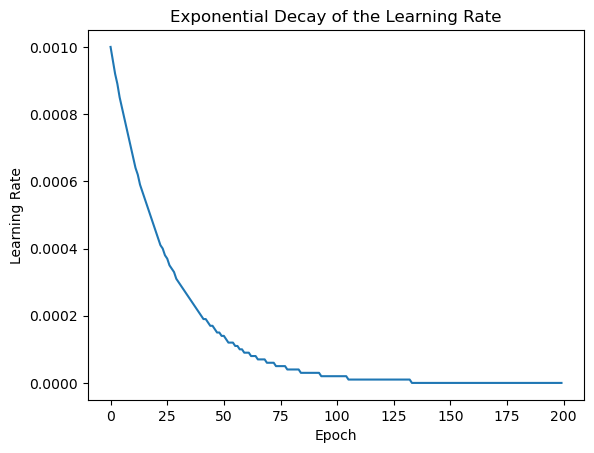

In [6]:
def exponential_decay(epoch,lr_ini=LR,decay_rate=DECAY_RATE,epochs=num_epochs):
    if epoch < epochs*0.001:
        return lr_ini
    else:
        return  lr_ini * np.exp(-decay_rate*epoch)
    
epochs = np.arange(num_epochs)
learning_rates = [round(exponential_decay(epoch),5) for epoch in epochs]


plt.plot(epochs, learning_rates, label="Learning Rate")
plt.title("Exponential Decay of the Learning Rate")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(False)
plt.show()  

### 4. Callbacks

In [7]:
lr_scheduler = LearningRateScheduler(lambda epoch: exponential_decay(epoch), verbose=1)
optimizer = Adam(learning_rate=LR)
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True,verbose=1)
save = save_in + '/Unet_CLASSIC_weights/Test5_Best_weights.weights.h5'
checkpoint_weight=tf.keras.callbacks.ModelCheckpoint(save,save_weights_only=True)
checkpoint_keras = tf.keras.callbacks.ModelCheckpoint(NamesKeras[4],save_best_only=True)
csv_logger = CSVLogger(name_logger, append=False)

I0000 00:00:1751245196.228257   69830 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2265 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1650, pci bus id: 0000:01:00.0, compute capability: 7.5


In [8]:
def conv_block_batchnorm(filters,x):
    conv = Conv2D(filters, (3, 3), padding=type_padding)(x)
    conv= BatchNormalization()(conv)
    conv = Activation(f_activation)(conv)
    conv = Conv2D(filters, (3, 3), padding=type_padding)(conv)
    conv= BatchNormalization()(conv)
    conv = Activation(f_activation)(conv)
    return conv
    
def conv_block(filters,x):
    conv = Conv2D(filters, (3, 3), activation=f_activation, padding=type_padding)(x)
    conv = Conv2D(filters, (3, 3), activation=f_activation, padding=type_padding)(conv)
    return conv    

def encoder(x,filters):
    conv = conv_block_batchnorm(filters,x)
    downsample = MaxPooling2D((2,2))(conv)
    return conv,downsample

def biLSTM(x,units=128):
    _, h, w, c = x.shape #Flatten spatial dimensions for LSTM
    x_reshaped = layers.Reshape((h*w, c))(x)
    x_bilstm = layers.Bidirectional(layers.LSTM(units, return_sequences=True))(x_reshaped) 
    x_bilstm = layers.Reshape((h, w, units*2))(x_bilstm)
    return x_bilstm

def decoder(x1,x2,filters,transpose=None):
    if transpose != None:
        conv_up = Conv2DTranspose(filters,(2,2),strides=(2, 2),padding=type_padding)(x1)
    else:
        conv_up = UpSampling2D((2, 2))(x1)
   
    concat=concatenate([conv_up,x2],axis = 3)
    up = conv_block(filters, concat)
    return up

In [9]:
def make_model():
    
    image_input = Input((img_height, img_width, channel))
    
    conv1,down_block1 = encoder (image_input, number_of_filters[0])
    conv2,down_block2 = encoder (down_block1 , number_of_filters[1])
    conv3,down_block3 = encoder (down_block2 , number_of_filters[2])
    conv4,down_block4 = encoder (down_block3 , number_of_filters[3])

    conv5 = conv_block(number_of_filters[4],down_block4)
   
 
    up6=decoder(conv5,conv4,number_of_filters[3],transpose='yes')
    up7=decoder(up6,conv3,number_of_filters[2],transpose='yes')
    up8=decoder(up7,conv2,number_of_filters[1],transpose='yes')
    up9=decoder(up8,conv1,number_of_filters[0],transpose='yes')

    flows_out = Conv2D(4, (1, 1), activation=f_activation_last,name='flows_output',padding="same")(up9)

    # construct model
    model =  keras.Model(inputs=image_input, outputs=[flows_out],name= model_name)
    
    model.summary()

  

    model.compile(optimizer=optimizer, 
              loss = 'mean_squared_error',
              
              metrics= ['mae', "root_mean_squared_error"] )

    return model  


### 5. Architecture

In [10]:
M=make_model()

Model: "Unet_CLASSIC"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 256,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 256,   │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 256,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 256,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 256,   │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 256,   │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 256,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 128,   │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 128,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 128,   │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 128,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 128,   │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 128,   │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 32, 128,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 64,    │        512 │ conv2d_4[0][0]  

 Total params: 7,763,460 (29.62 MB)

 Trainable params: 7,761,540 (29.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

### 6. Parameters Number

In [11]:
params_simple = M.count_params()
print('Parameters Number: ', params_simple)

Parameters Number:  7763460


### 7. Fitting

In [12]:
print("Starting training")
start_time_for_fit = time.time()
history = M.fit(train_ds,epochs=num_epochs,validation_data = val_ds,
                callbacks=[lr_scheduler,early_stopping,checkpoint_weight,checkpoint_keras])
end_time_for_fit = time.time()
Training_time = end_time_for_fit - start_time_for_fit
print(f"TRAINING TIME IN  {Training_time:.4f} segundos.")
    

Starting training

Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/200


/home/ppgi/miniconda3/envs/newEnviroment/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1751245202.136421   69907 service.cc:152] XLA service 0x7f6b580055a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1751245202.136436   69907 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2025-06-29 21:00:02.300119: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1751245203.229038   69907 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-06-29 21:00:05.001575: I ex

   1/1400 ━━━━━━━━━━━━━━━━━━━━ 8:35:23 22s/step - loss: 0.0776 - mae: 0.2187 - root_mean_squared_error: 0.2786

I0000 00:00:1751245219.131289   69907 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1400/1400 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0037 - mae: 0.0296 - root_mean_squared_error: 0.0549

2025-06-29 21:02:38.886339: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:549] Omitted potentially buggy algorithm eng14{k25=0} for conv %cudnn-conv-bias-activation.65 = (f32[10,512,4,16]{3,2,1,0}, u8[0]{0}) custom-call(f32[10,256,4,16]{3,2,1,0} %bitcast.1658, f32[512,256,3,3]{3,2,1,0} %bitcast.1665, f32[512]{0} %bitcast.1667), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="Unet_CLASSIC_1/conv2d_8_1/convolution" source_file="/home/ppgi/miniconda3/envs/newEnviroment/lib/python3.9/site-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kRelu","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false}
2025-06-29 21:02:39.131791: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_pi

1400/1400 ━━━━━━━━━━━━━━━━━━━━ 176s 110ms/step - loss: 0.0037 - mae: 0.0296 - root_mean_squared_error: 0.0549 - val_loss: 3.3096e-04 - val_mae: 0.0126 - val_root_mean_squared_error: 0.0182 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.0009607894391523232.
Epoch 2/200
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 151s 108ms/step - loss: 1.2841e-04 - mae: 0.0062 - root_mean_squared_error: 0.0113 - val_loss: 4.2969e-04 - val_mae: 0.0136 - val_root_mean_squared_error: 0.0207 - learning_rate: 9.6079e-04

Epoch 3: LearningRateScheduler setting learning rate to 0.0009231163463866358.
Epoch 3/200
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 152s 108ms/step - loss: 1.0404e-04 - mae: 0.0058 - root_mean_squared_error: 0.0102 - val_loss: 7.8350e-05 - val_mae: 0.0071 - val_root_mean_squared_error: 0.0089 - learning_rate: 9.2312e-04

Epoch 4: LearningRateScheduler setting learning rate to 0.0008869204367171575.
Epoch 4/200
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 151s 108ms/step - loss: 5.2242e-05 - m

### 8. Evaluation

In [13]:
results = M.evaluate(test_ds) 
print("Evaluation results:")
for name, value in zip(M.metrics_names, results):
    print(f"{name}: {value:.6f}")

200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 3.1156e-06 - mae: 0.0011 - root_mean_squared_error: 0.0018
Evaluation results:
loss: 0.000003
compile_metrics: 0.001119


### 9. Prediction

In [14]:
best_weights=save
M.load_weights(best_weights)

In [15]:
ytrue,ypred=predicting_error(test_ds,M)

*** Starting ***
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 802ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms

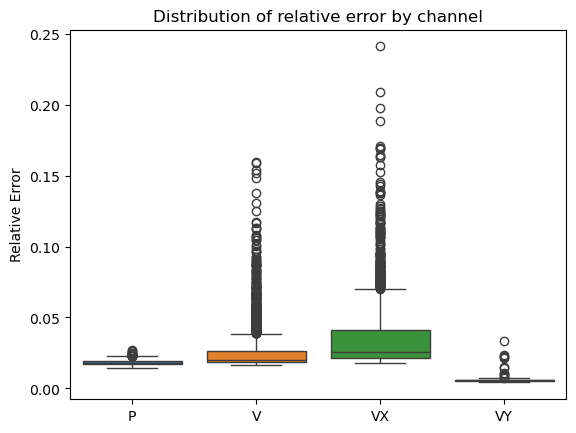

In [16]:
relative_error(ypred,ytrue)

In [17]:
metric_by_channels(ypred,ytrue)

p: MSE = 0.000006, MAE = 0.001878, RMSE =0.002514
v: MSE = 0.000008, MAE = 0.002164, RMSE =0.002790
vx: MSE = 0.000010, MAE = 0.002499, RMSE =0.003106
vy: MSE = 0.000007, MAE = 0.002173, RMSE =0.002633
MSE global: 0.000008
MAE global: 0.002179
MAE % global: 0.217852
RMSE global: 0.002770


### 10. Figures

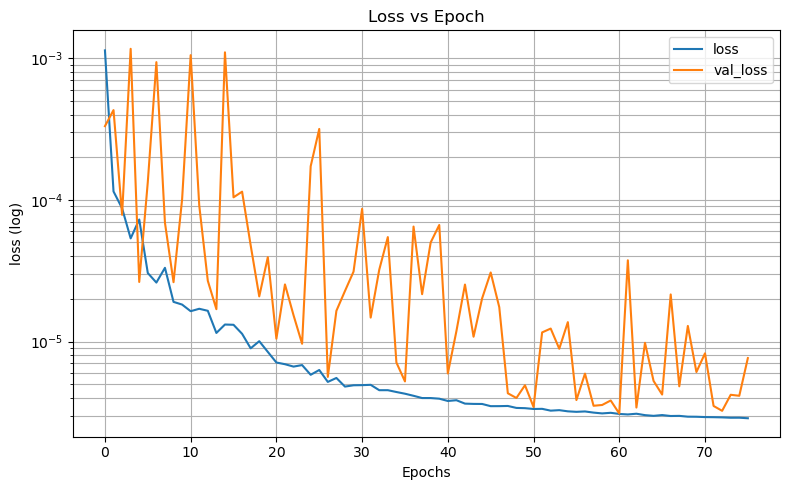

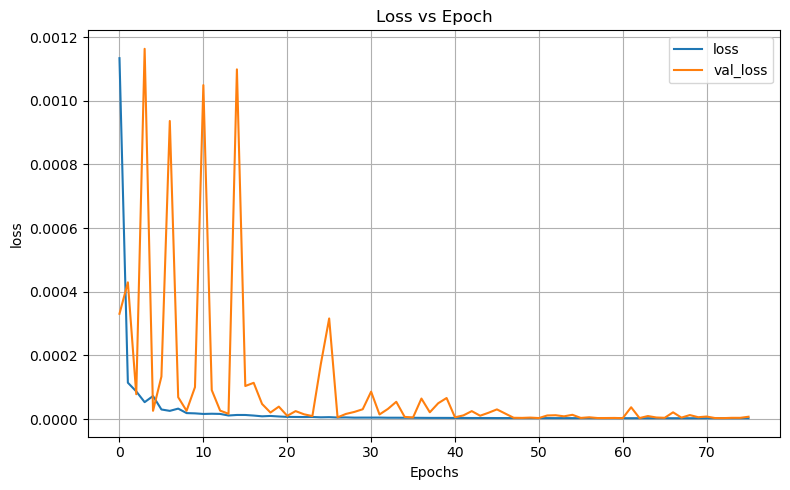

In [18]:
plot_model(history,'loss','val_loss',"Loss vs Epoch",True)

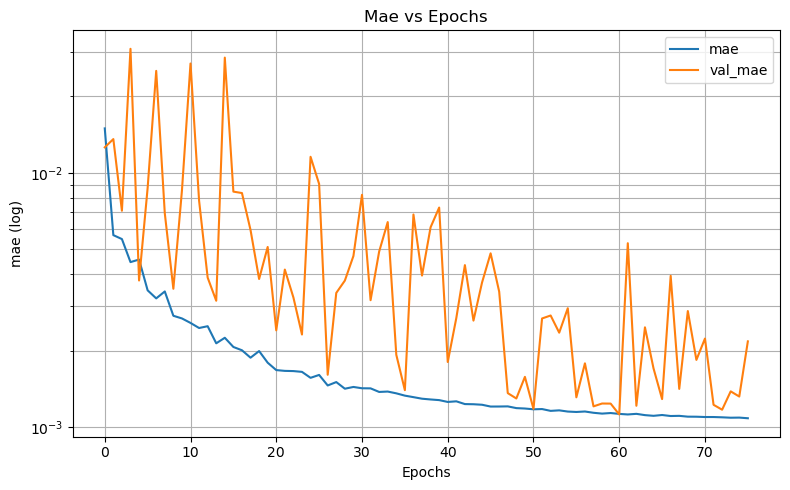

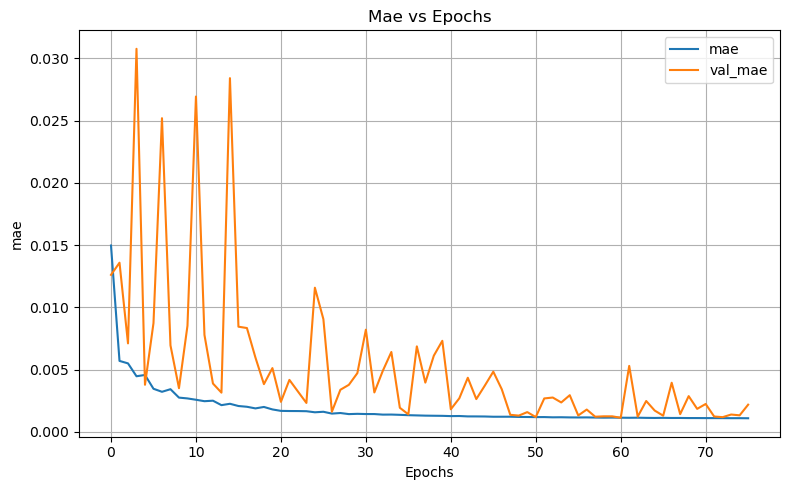

In [19]:
plot_model(history,'mae','val_mae',"Mae vs Epochs",True)

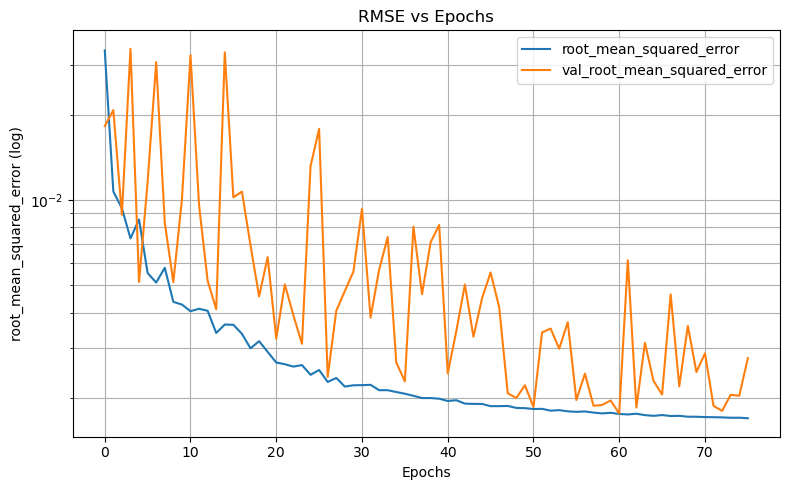

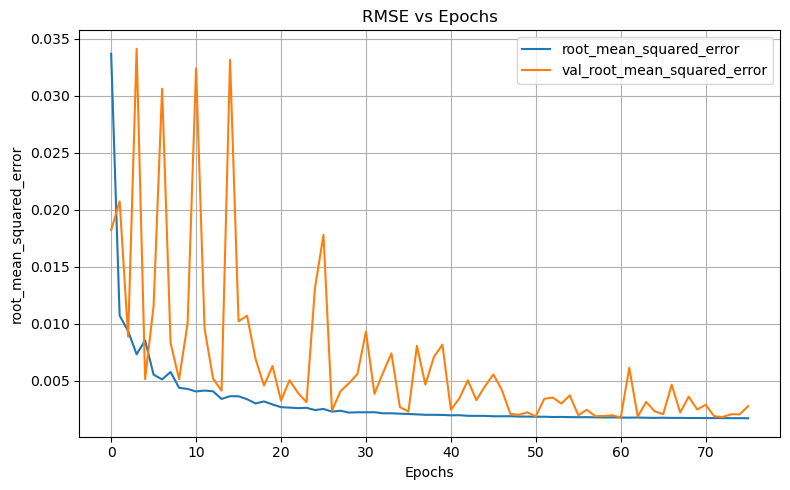

In [20]:
plot_model(history,'root_mean_squared_error','val_root_mean_squared_error',"RMSE vs Epochs",True)

### 11. Qualitative Visualization

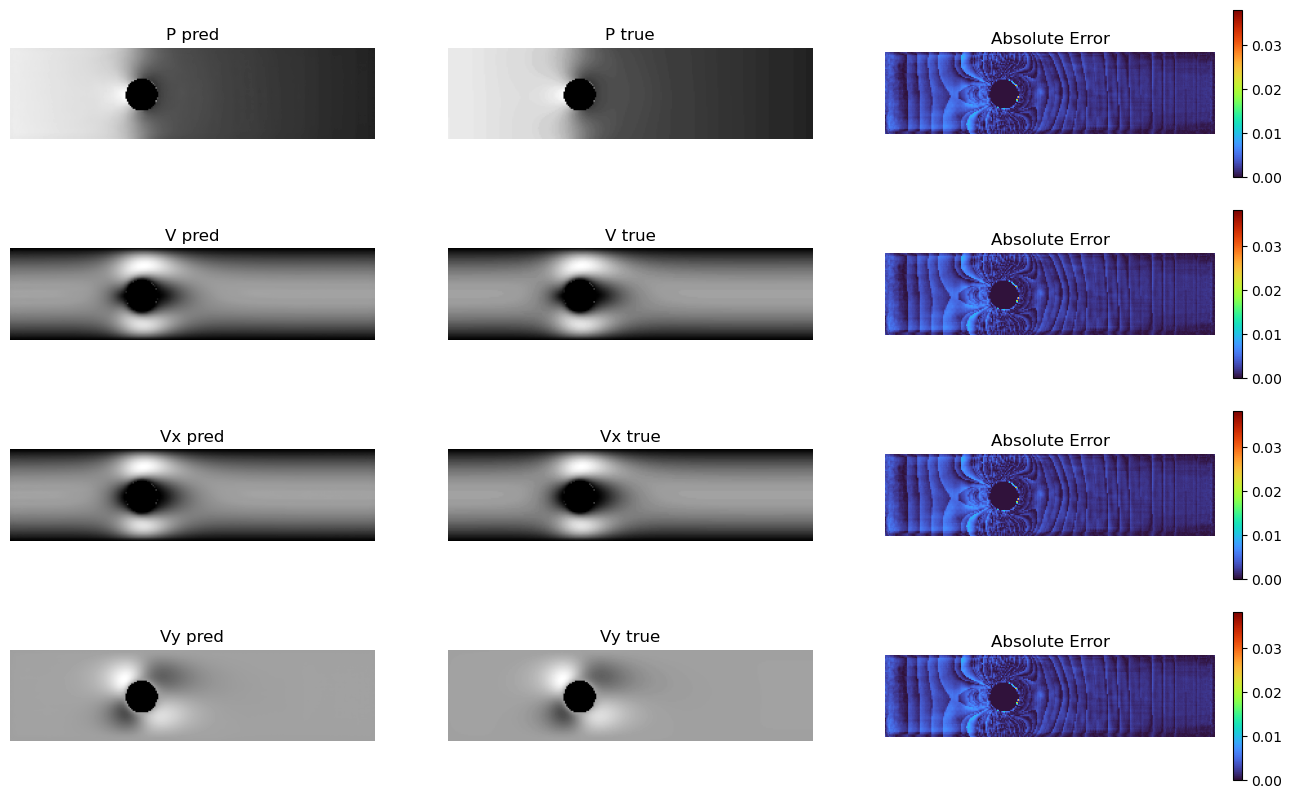

In [21]:
plotting(ytrue,ypred,'visualization_01')

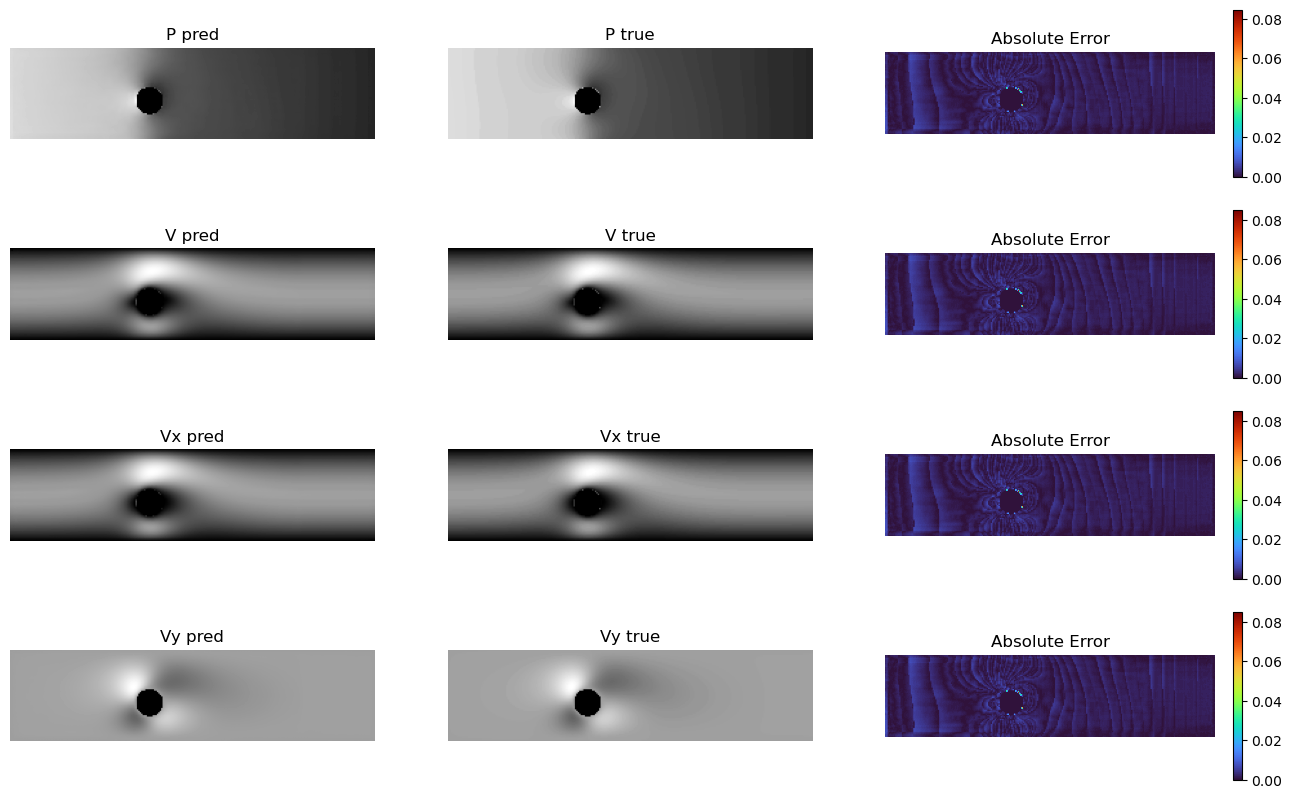

In [22]:
plotting(ytrue,ypred,'visualization_02')

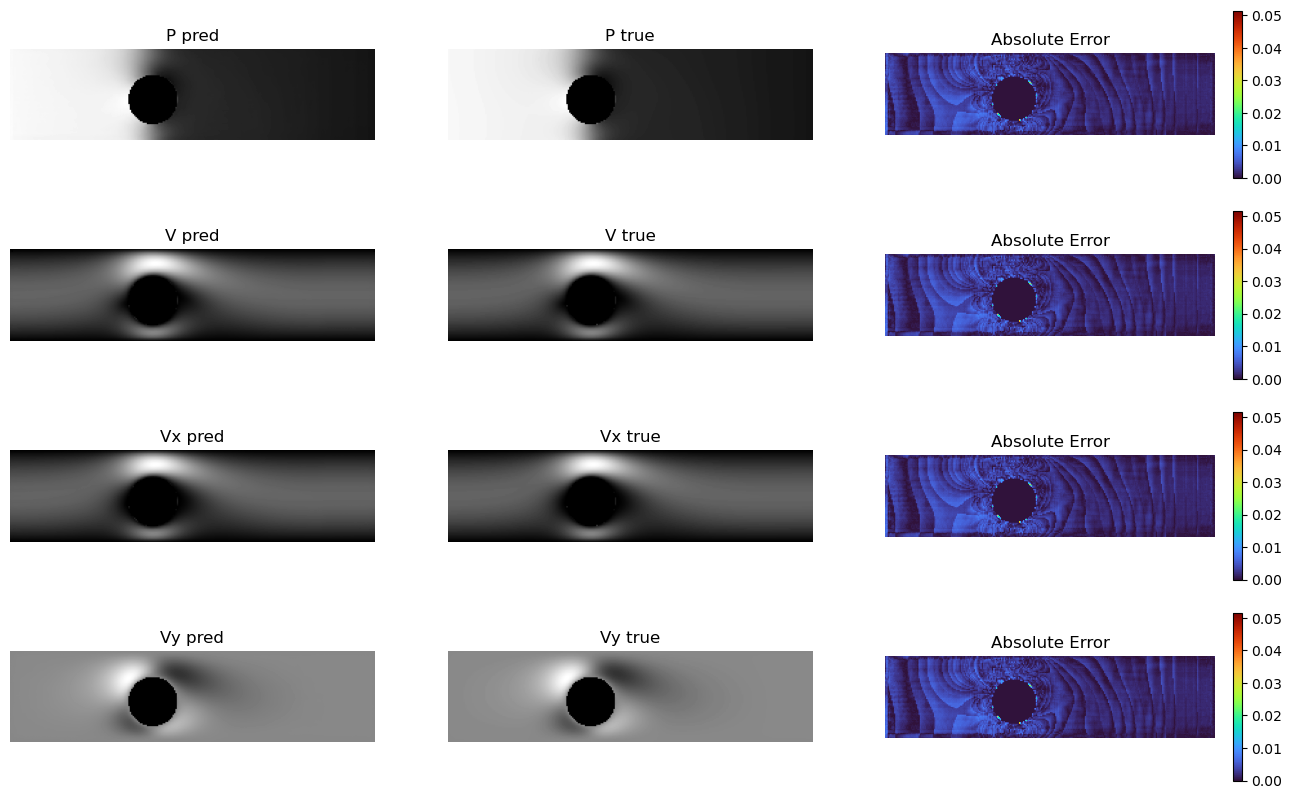

In [23]:
plotting(ytrue,ypred,'visualization_03')

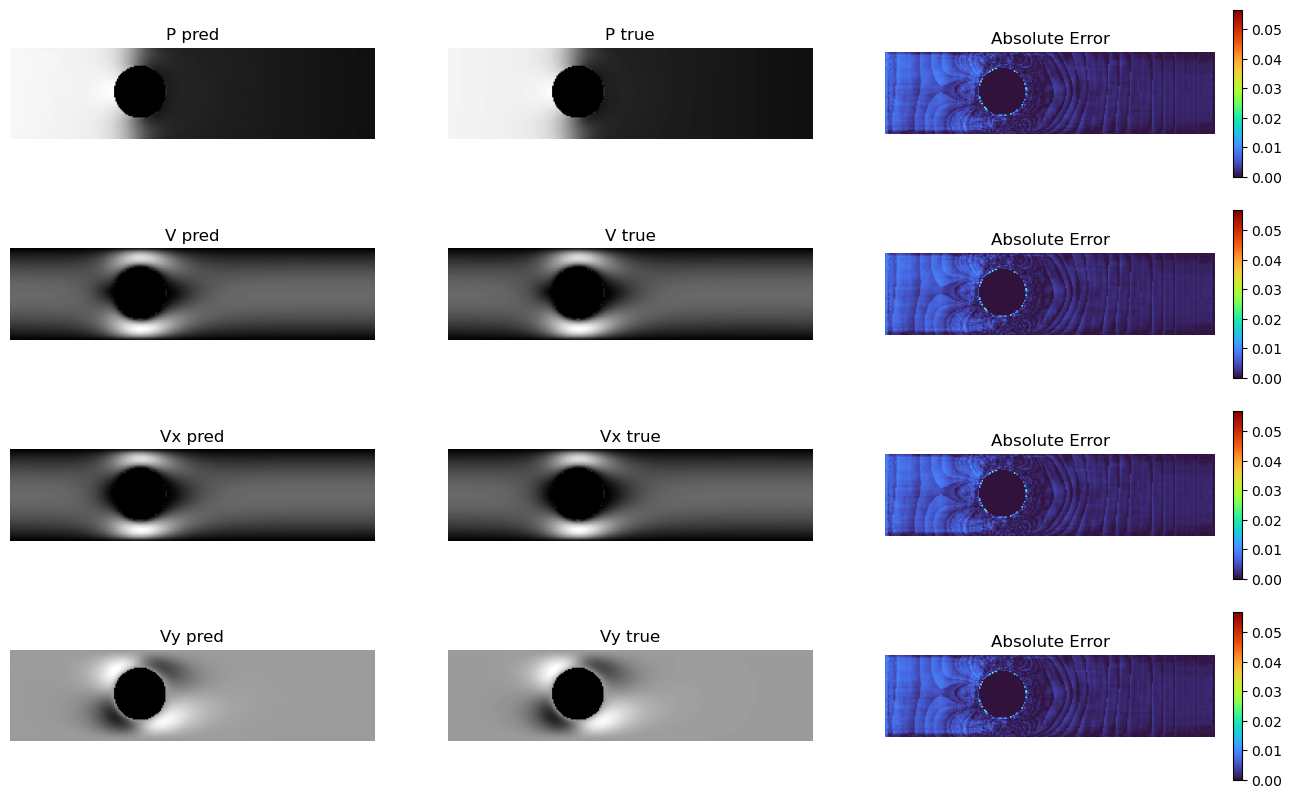

In [24]:
plotting(ytrue,ypred,'visualization_04')